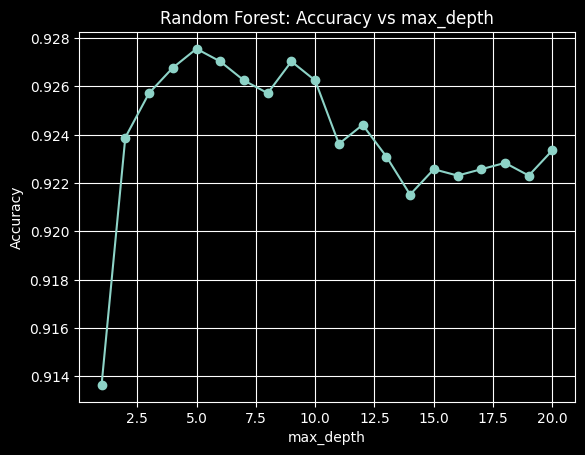

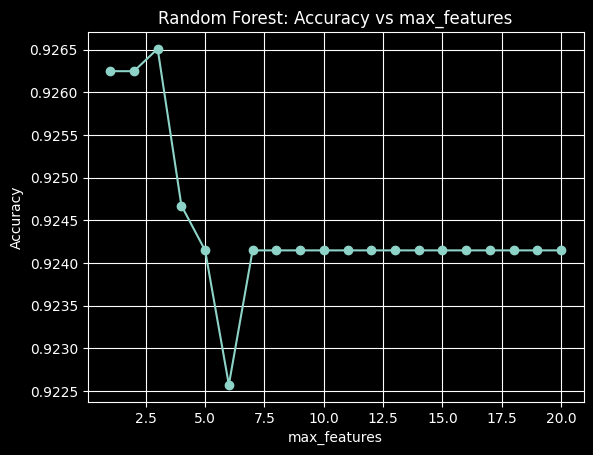

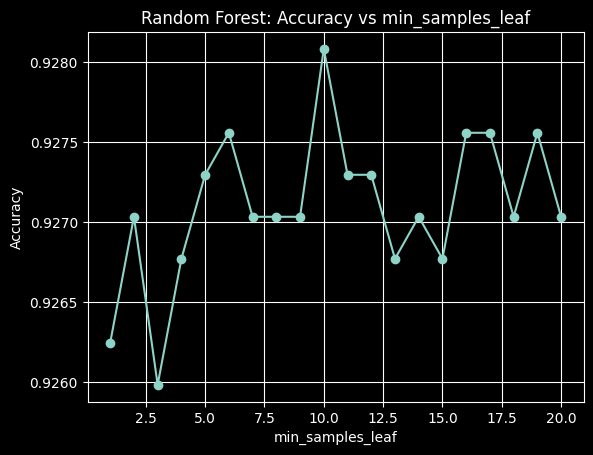


RF RESPONSE SUMMARY

max_depth: [(1, np.float64(0.9136482939632545)), (2, np.float64(0.9238845144356956)), (3, np.float64(0.9257217847769029)), (4, np.float64(0.926771653543307)), (5, np.float64(0.9275590551181102)), (6, np.float64(0.927034120734908)), (7, np.float64(0.926246719160105)), (8, np.float64(0.9257217847769029)), (9, np.float64(0.9270341207349082)), (10, np.float64(0.926246719160105)), (11, np.float64(0.9236220472440945)), (12, np.float64(0.9244094488188977)), (13, np.float64(0.9230971128608922)), (14, np.float64(0.9215223097112861)), (15, np.float64(0.9225721784776904)), (16, np.float64(0.9223097112860892)), (17, np.float64(0.9225721784776904)), (18, np.float64(0.9228346456692913)), (19, np.float64(0.9223097112860892)), (20, np.float64(0.9233595800524934))]
max_features: [(1, np.float64(0.926246719160105)), (2, np.float64(0.926246719160105)), (3, np.float64(0.9265091863517061)), (4, np.float64(0.9246719160104986)), (5, np.float64(0.9241469816272966)), (6, np.float64(0.9225

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ==============================
# Load dataset
# ==============================
df = pd.read_excel(r"../Rice_Cammeo_Osmancik.xlsx")

features = [
    'Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
    'Eccentricity', 'Convex_Area', 'Extent'
]

X = df[features]
y = df['Class']

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# ==============================
# Metric
# ==============================
def accuracy(cm):
    tn, fp, fn, tp = cm.ravel()
    return (tp + tn) / (tp + tn + fp + fn)

# ==============================
# CV setup
# ==============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==============================
# FIXED PARAMETERS
# ==============================
n_estimators = 200
bootstrap = True

# ==============================
# 1. max_depth curve
# ==============================
max_depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
depth_results = []

for d in max_depth_values:

    fold_scores = []

    for train_idx, test_idx in cv.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=d,
            bootstrap=bootstrap,
            random_state=42
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        cm = confusion_matrix(y_test, preds)
        fold_scores.append(accuracy(cm))

    depth_results.append(np.mean(fold_scores))

# ==============================
# 2. max_features curve
# ==============================
max_features_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
mf_results = []

for mf in max_features_values:

    fold_scores = []

    for train_idx, test_idx in cv.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=10,
            max_features=mf,
            bootstrap=bootstrap,
            random_state=42
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        cm = confusion_matrix(y_test, preds)
        fold_scores.append(accuracy(cm))

    mf_results.append(np.mean(fold_scores))

# ==============================
# 3. min_samples_leaf curve
# ==============================
leaf_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
leaf_results = []

for l in leaf_values:

    fold_scores = []

    for train_idx, test_idx in cv.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=10,
            min_samples_leaf=l,
            bootstrap=bootstrap,
            random_state=42
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        cm = confusion_matrix(y_test, preds)
        fold_scores.append(accuracy(cm))

    leaf_results.append(np.mean(fold_scores))

# ==============================
# PLOTS
# ==============================

plt.figure()
plt.plot(max_depth_values, depth_results, marker='o')
plt.title("Random Forest: Accuracy vs max_depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(max_features_values, mf_results, marker='o')
plt.title("Random Forest: Accuracy vs max_features")
plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(leaf_values, leaf_results, marker='o')
plt.title("Random Forest: Accuracy vs min_samples_leaf")
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# ==============================
# Summary printout
# ==============================
print("\nRF RESPONSE SUMMARY\n")

print("max_depth:", list(zip(max_depth_values, depth_results)))
print("max_features:", list(zip(max_features_values, mf_results)))
print("min_samples_leaf:", list(zip(leaf_values, leaf_results)))

In [1]:
# ------------------------------
# Import libraries
# ------------------------------
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# ------------------------------
# Load dataset
# ------------------------------
file_path = r"../Rice_Cammeo_Osmancik.xlsx"
df = pd.read_excel(file_path)

# select features & target
features = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
            'Eccentricity', 'Convex_Area', 'Extent']
X = df[features]
y = df['Class']  # target

# ------------------------------
# Helper function for safe division
# ------------------------------
def safe_div(a, b):
    return a / b if b != 0 else np.nan

# ------------------------------
# Function to compute metrics from confusion matrix
# ------------------------------
def compute_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    return np.array([
        safe_div(tp + tn, tp + tn + fp + fn),   # Accuracy
        safe_div(tp, tp + fn),                  # Sensitivity / Recall
        safe_div(tn, tn + fp),                  # Specificity
        safe_div(tp, tp + fp),                  # Precision
        safe_div(2 * tp, 2 * tp + fp + fn),     # F1-Score
        safe_div(tn, tn + fn),                  # Negative Predictive Value
        safe_div(fp, tn + fp),                  # False Positive Rate
        safe_div(fp, tp + fp),                  # False Discovery Rate
        safe_div(fn, tp + fn)                   # False Negative Rate
    ])

# ------------------------------
# Function 1: Train all models with cross-validation
# ------------------------------
def train_models_cv(X, y, cv_splits=10, random_state=42):
    """
    Train 7 models on X, y using StratifiedKFold CV.
    Returns a DataFrame of mean metrics (rows=measures, columns=models)
    """
    # define models
    models = {
        "LR": LogisticRegression(max_iter=1000),
        "MLP": MLPClassifier(max_iter=1000),
        "SVM": SVC(),
        "DT": DecisionTreeClassifier(),
        "RF": RandomForestClassifier(),
        "NB": GaussianNB(),
        "k-NN": KNeighborsClassifier(n_neighbors=1)
    }

    # setup cross-validation
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    results = {}

    for name, model in models.items():
        fold_metrics = []

        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            cm = confusion_matrix(y_test, preds)
            fold_metrics.append(compute_metrics(cm))

        results[name] = np.nanmean(fold_metrics, axis=0)

    # metrics names
    measures = [
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision",
        "F1-Score",
        "Negative Predictive Value",
        "False Positive Rate",
        "False Discovery Rate",
        "False Negative Rate"
    ]

    # create DataFrame (rows=measures, columns=models)
    results_df = pd.DataFrame(results, index=measures)
    return results_df * 100  # convert to percentage

# ------------------------------
# Function 2: Get best model per measure
# ------------------------------
def get_best_models(results_df):
    """
    For each measure, return the model with highest value and its score.
    """
    best_models = results_df.idxmax(axis=1)
    best_values = results_df.max(axis=1)

    print("\nBest model per measure:\n")
    for measure in results_df.index:
        print(f"{measure:30s} -> Best: {best_models[measure]} ({best_values[measure]:.2f}%)")

    print("\nNumber of wins per model:\n")
    print(best_models.value_counts())

    return best_models, best_values

# ------------------------------
# Run all models and show metrics
# ------------------------------
results_df = train_models_cv(X, y)
display(results_df.round(2))  # show all metrics in table
best_models, best_scores = get_best_models(results_df)  # print best models summary

,LR,MLP,SVM,DT,RF,NB,k-NN
Accuracy,93.04,62.13,88.06,88.35,92.41,91.10,86.67
Sensitivity,94.50,92.52,92.89,90.18,93.53,92.80,88.62
Specificity,91.10,21.47,81.60,85.89,90.92,88.83,84.05
Precision,93.44,62.74,87.13,89.56,93.26,91.77,88.15
F1-Score,93.96,73.75,89.90,89.85,93.38,92.27,88.37
Negative Predictive Value,92.54,81.56,89.61,86.79,91.35,90.26,84.73
False Positive Rate,8.90,78.53,18.40,14.11,9.08,11.17,15.95
False Discovery Rate,6.56,37.26,12.87,10.44,6.74,8.23,11.85
False Negative Rate,5.50,7.48,7.11,9.82,6.47,7.20,11.38



Best model per measure:

Accuracy                       -> Best: LR (93.04%)
Sensitivity                    -> Best: LR (94.50%)
Specificity                    -> Best: LR (91.10%)
Precision                      -> Best: LR (93.44%)
F1-Score                       -> Best: LR (93.96%)
Negative Predictive Value      -> Best: LR (92.54%)
False Positive Rate            -> Best: MLP (78.53%)
False Discovery Rate           -> Best: MLP (37.26%)
False Negative Rate            -> Best: k-NN (11.38%)

Number of wins per model:

LR      6
MLP     2
k-NN    1
Name: count, dtype: int64
